# Predicting Partner Churn in a B2B Partner Management Program

Over the years working with partner ecosystems, one question keeps coming up: which partners are quietly heading for the exit, and can we catch that early enough to do something about it? Partner churn is expensive — replacing a partner means losing months of ramp-up, enablement investment, and the relationship equity that took a long time to build. If we can flag at-risk partners a quarter ahead of time, the partner management team can prioritize outreach, re-engagement, or renegotiation before the relationship is unrecoverable instead of finding out when the partner has already stopped transacting.

This notebook walks through building a churn prediction model for a partner management program, structured the way I'd actually approach this at work: understand the data deeply before touching a model, then let the models confirm (or challenge) that understanding.

**The dataset used here is fully synthetic.** It was generated to reflect realistic partner dynamics — growth/decline patterns, recurring annual seasonality, engagement signals, NPS trends, competitor relationships — based on how these programs actually behave in practice, but it does not come from any real company or partner.

This version of the analysis is a significant methodological upgrade over an earlier pass, closing six gaps I wasn't happy leaving in place:

1. **Fixed a seasonality-trend bug.** The original `gtv_trend_3m` feature compared a partner's last 3 months to their prior 3 months — for a seasonal partner sampled right after their annual peak, that reads a completely normal post-holiday dip as a churn-risk decline. I added a year-over-year trend comparison and a proper seasonal-deviation feature (fit via STL decomposition) that nets out the expected seasonal shape, so "just in their normal low season" and "actually underperforming" are no longer conflated.
2. **Added a cold-start segment for new partners.** A partner with 4 months of tenure can't have a reliable multi-year trend. Rather than force unreliable features on them, partners under 9 months tenure get a distinct, simpler feature set (a cohort-ramp benchmark instead of a trend/seasonality block), flagged explicitly via a `scoring_path` column.
3. **Switched to a temporal train/validation/test split.** The dataset now contains three quarterly snapshots per partner — not one — so the model can be trained on earlier snapshots and evaluated on a later one, mirroring how it will actually be used once deployed (retrained periodically, then scoring the *current* book going forward). A random split, which the original version used, silently assumes the model is deployed on data from the same time window it was trained on — never true in practice.
4. A **cost-based decision threshold**, replacing arbitrary risk-tier cutoffs with one derived from the real asymmetry between an unnecessary outreach call and a missed high-value churn.
5. **SHAP-based explanations**, so a partner manager can see exactly *why* a specific partner was flagged, not just that they were.
6. A **complementary survival-analysis view** (Cox Proportional Hazards), estimating *when* a partner is likely to churn, not just *whether* — useful for sequencing outreach by urgency, not just risk level.

Since items 1 and 2 change the underlying feature set, everything downstream in this notebook — the temporal split, the cost threshold, the SHAP analysis — runs against the *fixed* features, not the original ones. I'll call out that dependency again where it matters.

The target variable is `churned_next_quarter`: whether a partner stops being active in the following quarter. Since missing an at-risk partner is far costlier than flagging a healthy one by mistake (a false alarm just costs a check-in call; a missed churn costs the whole relationship), **recall** is the metric I care about most, alongside precision, F1, and ROC-AUC — refined further in the cost-threshold section into an explicit dollar-cost framing.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    precision_recall_curve
)

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
RANDOM_STATE = 42
NEW_PARTNER_TENURE_MONTHS = 9  # matches DEFAULT_COLD_START_TENURE_MONTHS in src/data_pipeline.py

# Make the reusable data pipeline importable from the project root
sys.path.insert(0, str(Path("..").resolve()))
from src.data_pipeline import load_partner_snapshots, load_gtv_history

IMAGES_DIR = Path("../images")
IMAGES_DIR.mkdir(exist_ok=True)

### Loading the data

Earlier versions of this notebook called `load_and_build_dataset` on a single static+history pair to build one point-in-time snapshot. That's no longer the right entry point: `generate_dataset.py` now calls `src/data_pipeline.py`'s `build_snapshot_dataset` once at generation time to produce **three** quarterly snapshots per partner — `train`, `validation`, and `test` — each with features computed strictly from GTV history truncated to that snapshot's own cutoff month (no information from a later snapshot ever reaches an earlier one). I load that combined table directly here, plus the full GTV history for the time-series EDA below.

In [2]:
snapshots_df = load_partner_snapshots("../data/partner_snapshots.csv")
gtv_history = load_gtv_history("../data/partner_gtv_history.csv")

print("Snapshot dataset:", snapshots_df.shape)
print(snapshots_df["snapshot_role"].value_counts().to_string())
print("\nGTV history:", gtv_history.shape, f"-> {gtv_history['month_index'].nunique()} months per partner")
snapshots_df.head()

Snapshot dataset: (3000, 28)
snapshot_role
train         1000
validation    1000
test          1000

GTV history: (33000, 3) -> 33 months per partner


,partner_id,region,vertical,partner_tier,months_as_partner,nps_score,nps_trend,support_tickets_last_quarter,avg_resolution_time_days,engagement_score,...,gtv_volatility,seasonal_autocorr_lag12,has_seasonality,gtv_vs_peers,gtv_vs_market_growth,gtv_seasonal_deviation_pct,gtv_ramp_vs_cohort,scoring_path,snapshot_role,snapshot_cutoff_month
0,partner_1,LATAM,Retail,Certified,32,4,stable,1,5.5,69.7,...,0.0918,-0.3353,0,0.5714,-15.32,0.00,0.0,mature,train,26
1,partner_2,NA,Tech,Registered,45,7,improving,0,4.0,71.1,...,0.1057,-0.0410,0,0.4359,3.52,0.00,0.0,mature,train,26
2,partner_3,APAC,Retail,Strategic,34,8,stable,1,0.5,53.1,...,0.2021,-0.1168,0,0.8571,9.09,0.00,0.0,mature,train,26
3,partner_4,LATAM,Retail,Certified,31,6,stable,0,6.0,78.5,...,0.2692,0.9075,1,0.4286,43.84,0.34,0.0,mature,train,26
4,partner_5,EMEA,Manufacturing,Registered,24,8,improving,5,5.7,65.4,...,0.1028,-0.6057,0,0.3077,-4.90,0.00,0.0,mature,train,26


In [3]:
snapshots_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   partner_id                    3000 non-null   object 
 1   region                        3000 non-null   object 
 2   vertical                      3000 non-null   object 
 3   partner_tier                  3000 non-null   object 
 4   months_as_partner             3000 non-null   int64  
 5   nps_score                     3000 non-null   int64  
 6   nps_trend                     3000 non-null   object 
 7   support_tickets_last_quarter  3000 non-null   int64  
 8   avg_resolution_time_days      3000 non-null   float64
 9   engagement_score              3000 non-null   float64
 10  days_since_last_contact       3000 non-null   int64  
 11  num_active_deals              3000 non-null   int64  
 12  has_competitor_relationship   3000 non-null   int64  
 13  chu

## 2. Exploratory Data Analysis

This is where I spend most of my time before ever fitting a model. In a real partner program, I'd want to know — just from looking at the data — which signals actually separate the partners who leave from the ones who stay, whether the seasonality fix and cold-start segment behave the way I intended, and whether there's anything broken or suspicious in the data itself.

**One important methodological point up front: everything in this EDA section runs against the `train` snapshot only, never `validation` or `test`.** This extends the temporal split's no-leakage principle to the EDA stage — decisions I make here (which features look interesting, what I expect the model to find) shouldn't be informed by data the model won't see until evaluation.

In [4]:
train_df = snapshots_df[snapshots_df["snapshot_role"] == "train"].reset_index(drop=True)
print(f"EDA dataset (train snapshot only): {train_df.shape}")

EDA dataset (train snapshot only): (1000, 28)


### 2.1 Churn rate and class balance

Train-snapshot churn rate: 20.0%
churned_next_quarter
0    800
1    200
Name: count, dtype: int64


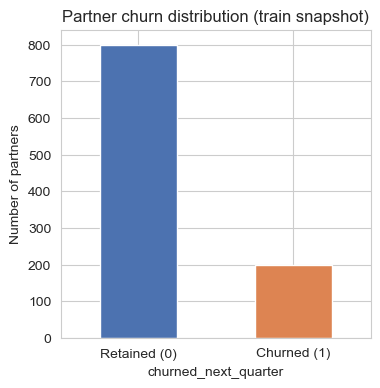

In [5]:
churn_rate = train_df["churned_next_quarter"].mean()
print(f"Train-snapshot churn rate: {churn_rate:.1%}")
print(train_df["churned_next_quarter"].value_counts())

ax = train_df["churned_next_quarter"].value_counts().sort_index().plot(
    kind="bar", color=["#4C72B0", "#DD8452"], figsize=(4, 4)
)
ax.set_xticklabels(["Retained (0)", "Churned (1)"], rotation=0)
ax.set_ylabel("Number of partners")
ax.set_title("Partner churn distribution (train snapshot)")
plt.show()

About one in five partners churns next quarter — consistent with the ~20% target the synthetic generator calibrates to at every snapshot. This is a meaningful class imbalance (roughly 4:1), which is why recall, precision, F1, and ROC-AUC all get reported rather than just accuracy.

### 2.2 Distribution of key features by churn status

The feature set is larger now than in the original version — it includes the new year-over-year trend, seasonal deviation, cold-start ramp feature, and `scoring_path`. Let's look at the numeric features split by churn status.

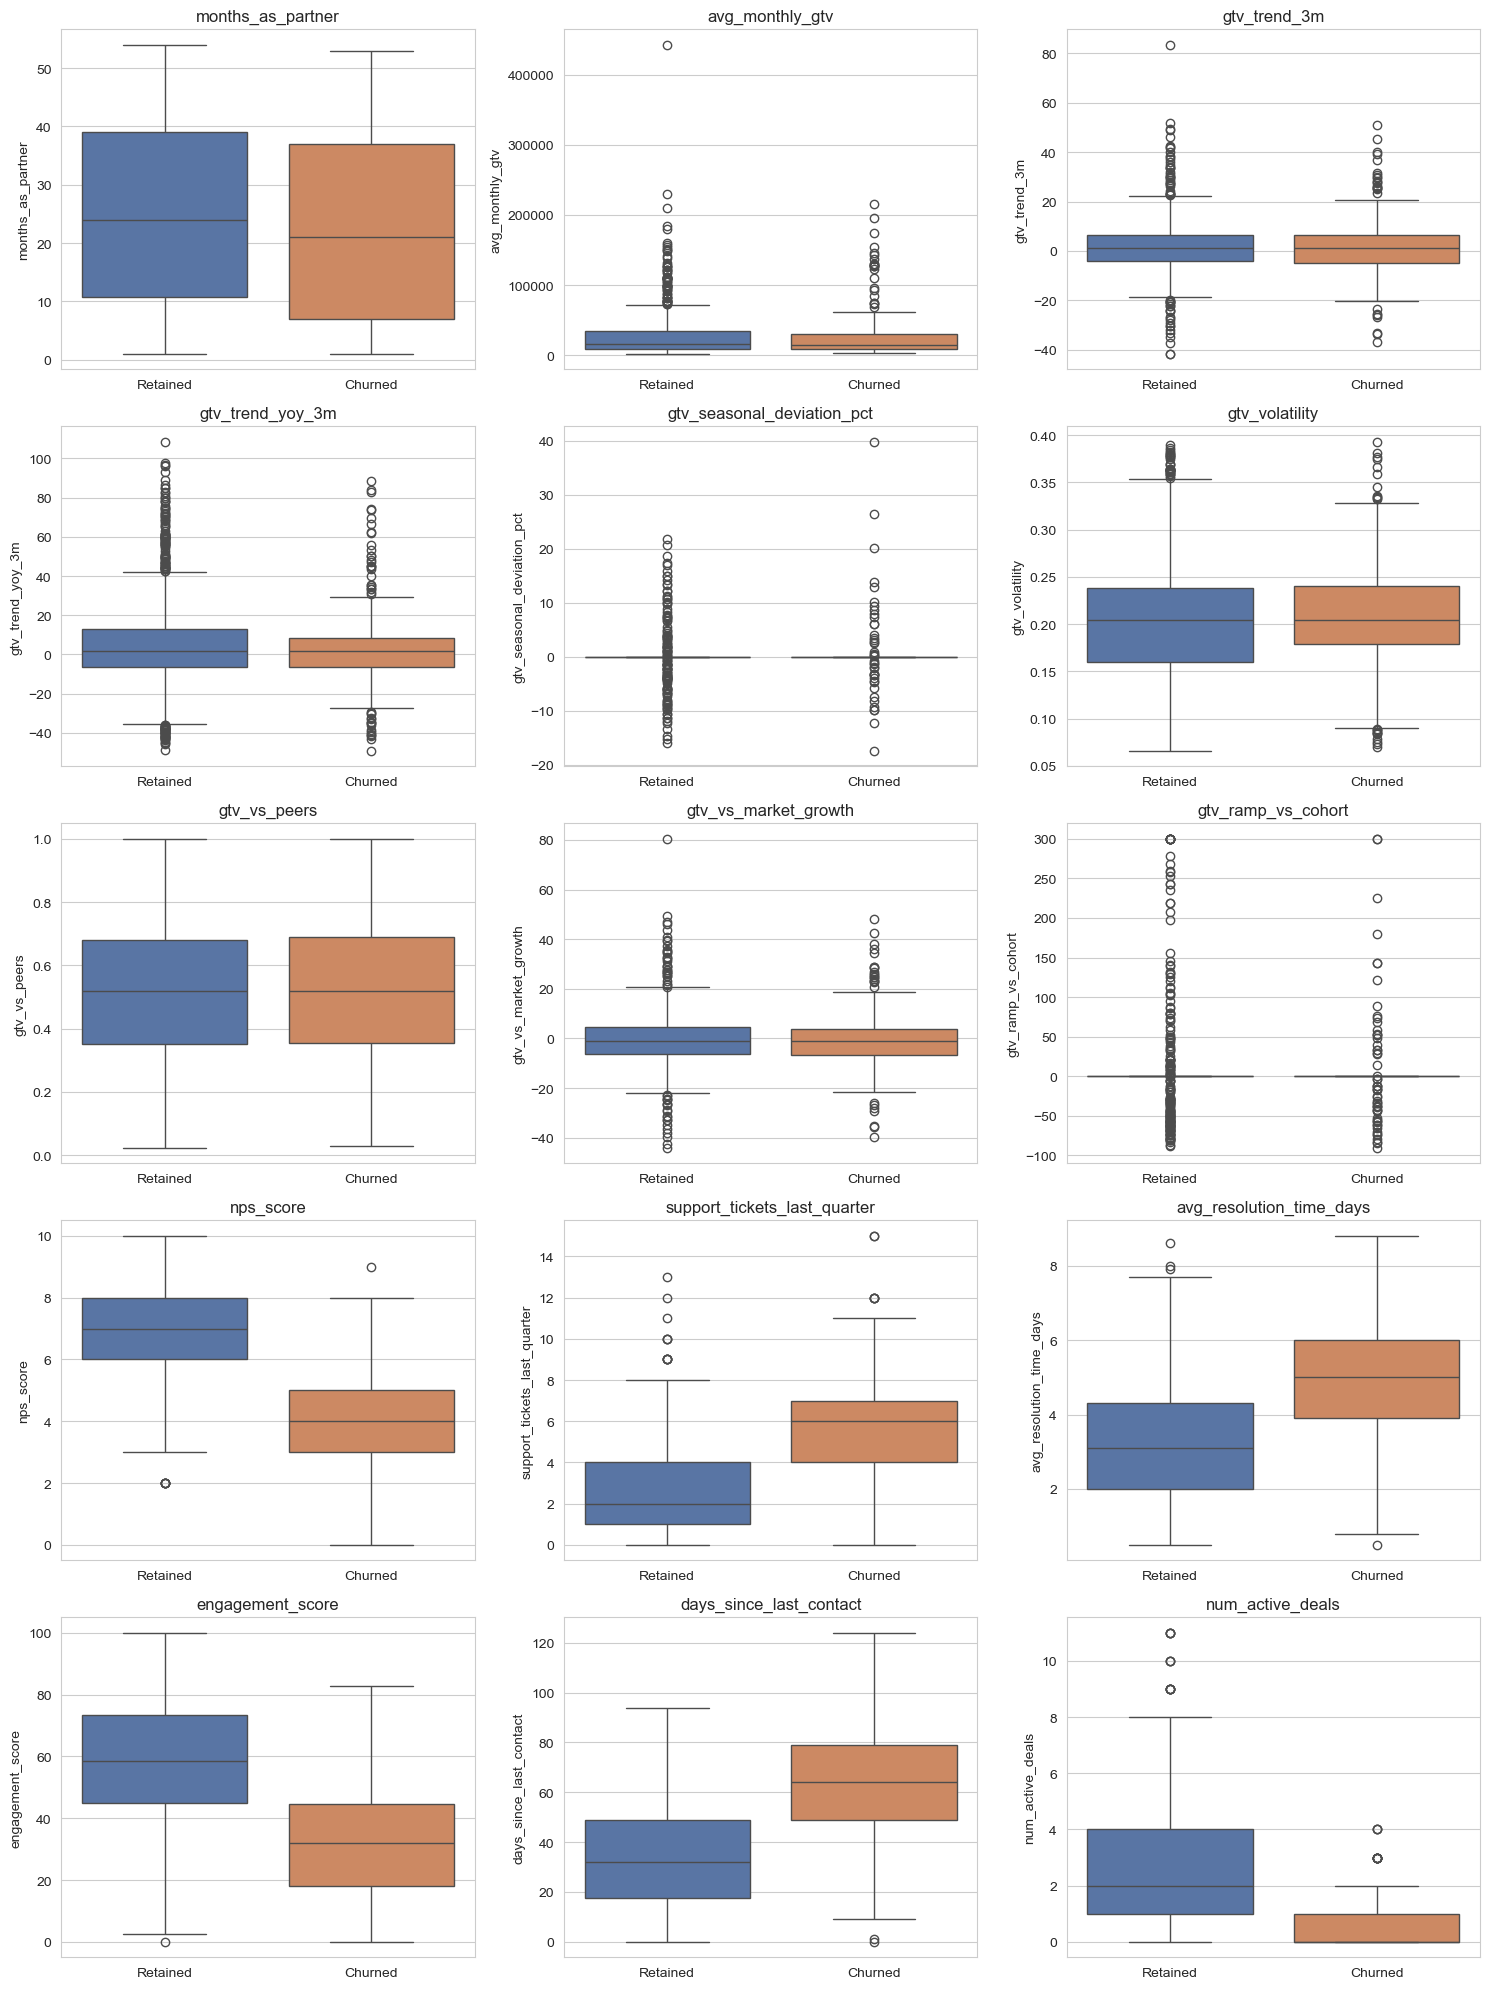

In [6]:
numeric_features = [
    "months_as_partner", "avg_monthly_gtv", "gtv_trend_3m", "gtv_trend_yoy_3m",
    "gtv_seasonal_deviation_pct", "gtv_volatility", "gtv_vs_peers", "gtv_vs_market_growth",
    "gtv_ramp_vs_cohort", "nps_score", "support_tickets_last_quarter",
    "avg_resolution_time_days", "engagement_score", "days_since_last_contact", "num_active_deals",
]

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
for ax, col in zip(axes.ravel(), numeric_features):
    sns.boxplot(
        data=train_df, x="churned_next_quarter", y=col, ax=ax,
        hue="churned_next_quarter", palette=["#4C72B0", "#DD8452"], legend=False
    )
    ax.set_xticklabels(["Retained", "Churned"])
    ax.set_xlabel("")
    ax.set_title(col)

plt.tight_layout()
plt.show()

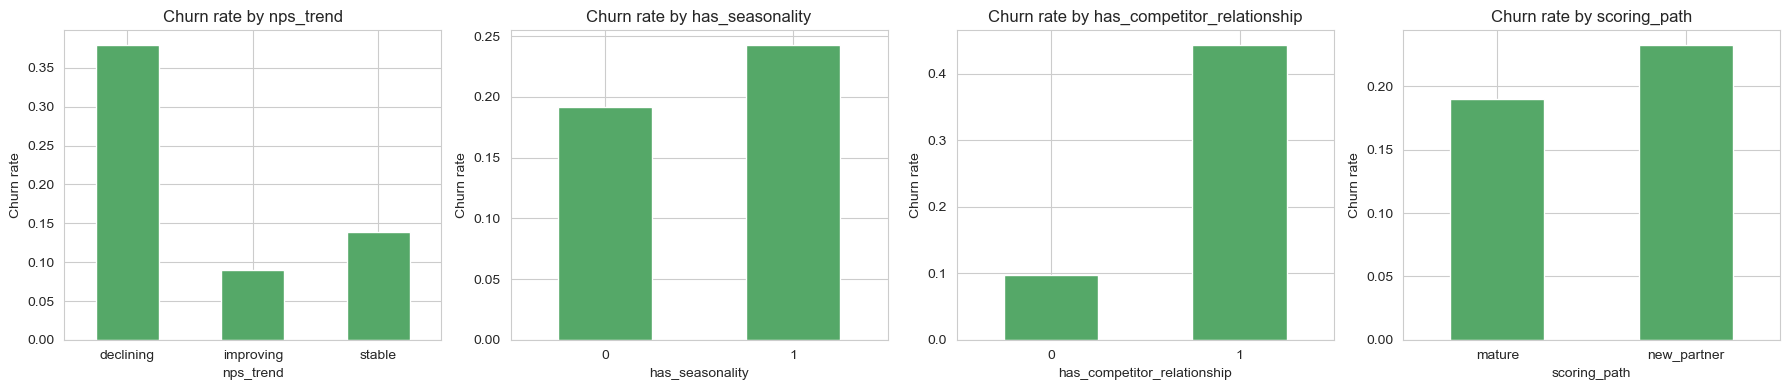

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, ["nps_trend", "has_seasonality", "has_competitor_relationship", "scoring_path"]):
    rate = train_df.groupby(col)["churned_next_quarter"].mean()
    rate.plot(kind="bar", ax=ax, color="#55A868")
    ax.set_ylabel("Churn rate")
    ax.set_title(f"Churn rate by {col}")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Churned partners skew toward negative GTV trend, lower NPS, lower engagement, longer gaps since last contact, more support tickets, longer resolution times, fewer active deals, and a much higher rate of competitor relationships — consistent with the original version. `has_seasonality` still looks close to flat across churn status, confirming that having a seasonal business pattern isn't itself a risk factor. `scoring_path` shows a modest churn-rate difference between mature and new partners, worth keeping an eye on once we get to modeling.

### 2.3 Churn rate by segment (region, vertical, tier)

Tier names updated: `Registered` / `Certified` / `Strategic`, replacing the original scheme.

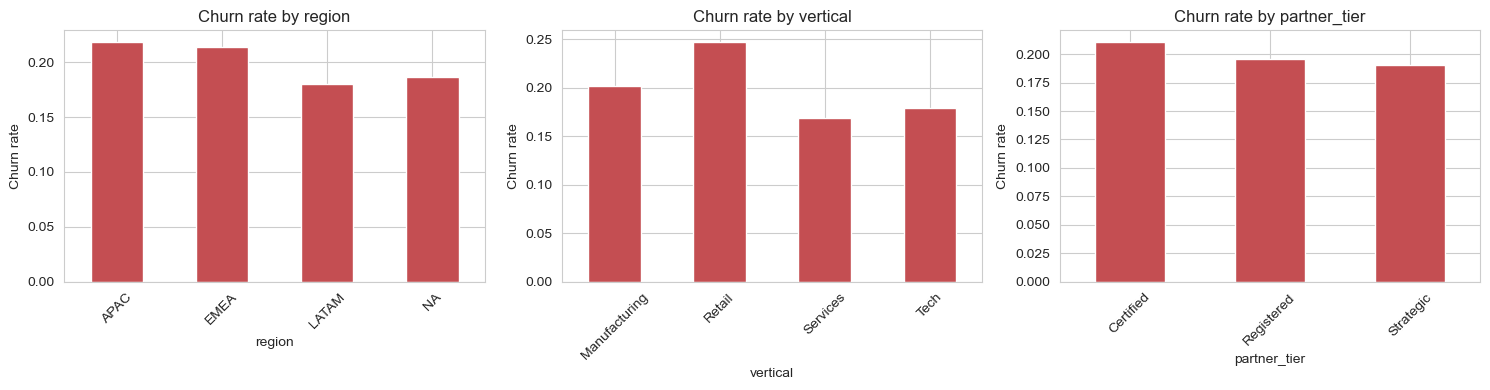

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["region", "vertical", "partner_tier"]):
    train_df.groupby(col)["churned_next_quarter"].mean().plot(kind="bar", ax=ax, color="#C44E52")
    ax.set_ylabel("Churn rate")
    ax.set_title(f"Churn rate by {col}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "churn_rate_by_tier_region.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Correlation heatmap

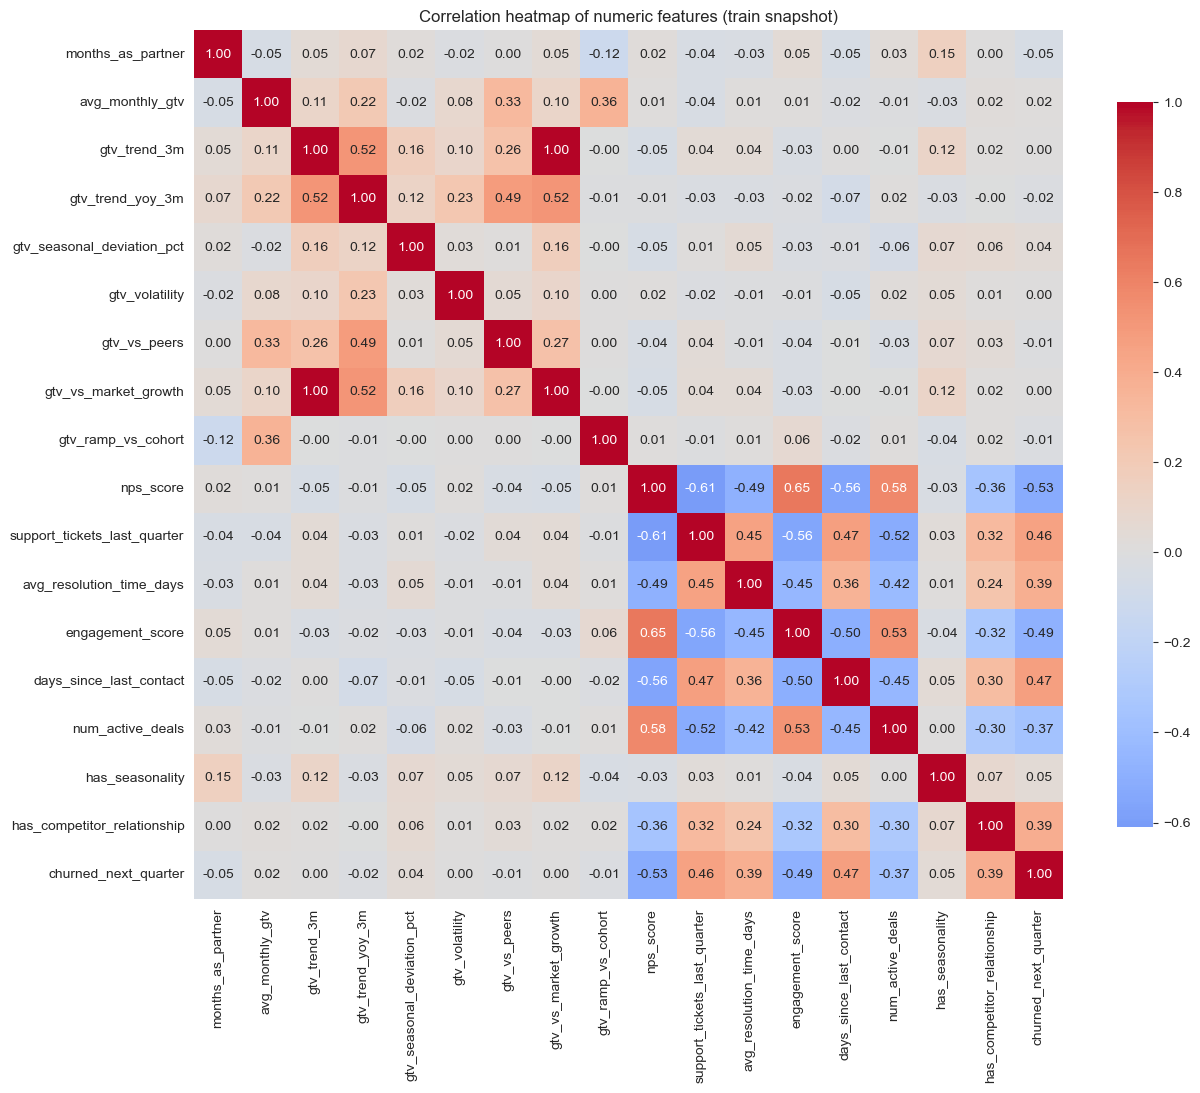

In [9]:
corr_cols = numeric_features + ["has_seasonality", "has_competitor_relationship", "churned_next_quarter"]

plt.figure(figsize=(13, 11))
corr = train_df[corr_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation heatmap of numeric features (train snapshot)")
plt.tight_layout()
plt.show()

`churned_next_quarter` still correlates most strongly with `gtv_trend_3m`, `nps_score`, `engagement_score`, `days_since_last_contact`, and `has_competitor_relationship`. The new `gtv_trend_yoy_3m` and `gtv_seasonal_deviation_pct` correlate more weakly with the label than the raw `gtv_trend_3m` does — which makes sense: the synthetic churn-generating process itself still uses the lightweight `gtv_trend_3m` as an input (it's a fine choice for the *label generator*, which needs one consistent trend signal), so the new features aren't competing to predict that same mechanism. Their value isn't in correlating with this particular label — it's in giving the model an undistorted read on seasonal partners specifically, which the next section demonstrates directly.

### 2.5 GTV time series: churned vs. retained, across the full history

Using the full GTV history (all 33 months, independent of any single snapshot's truncation), let's look at individual partner trajectories.

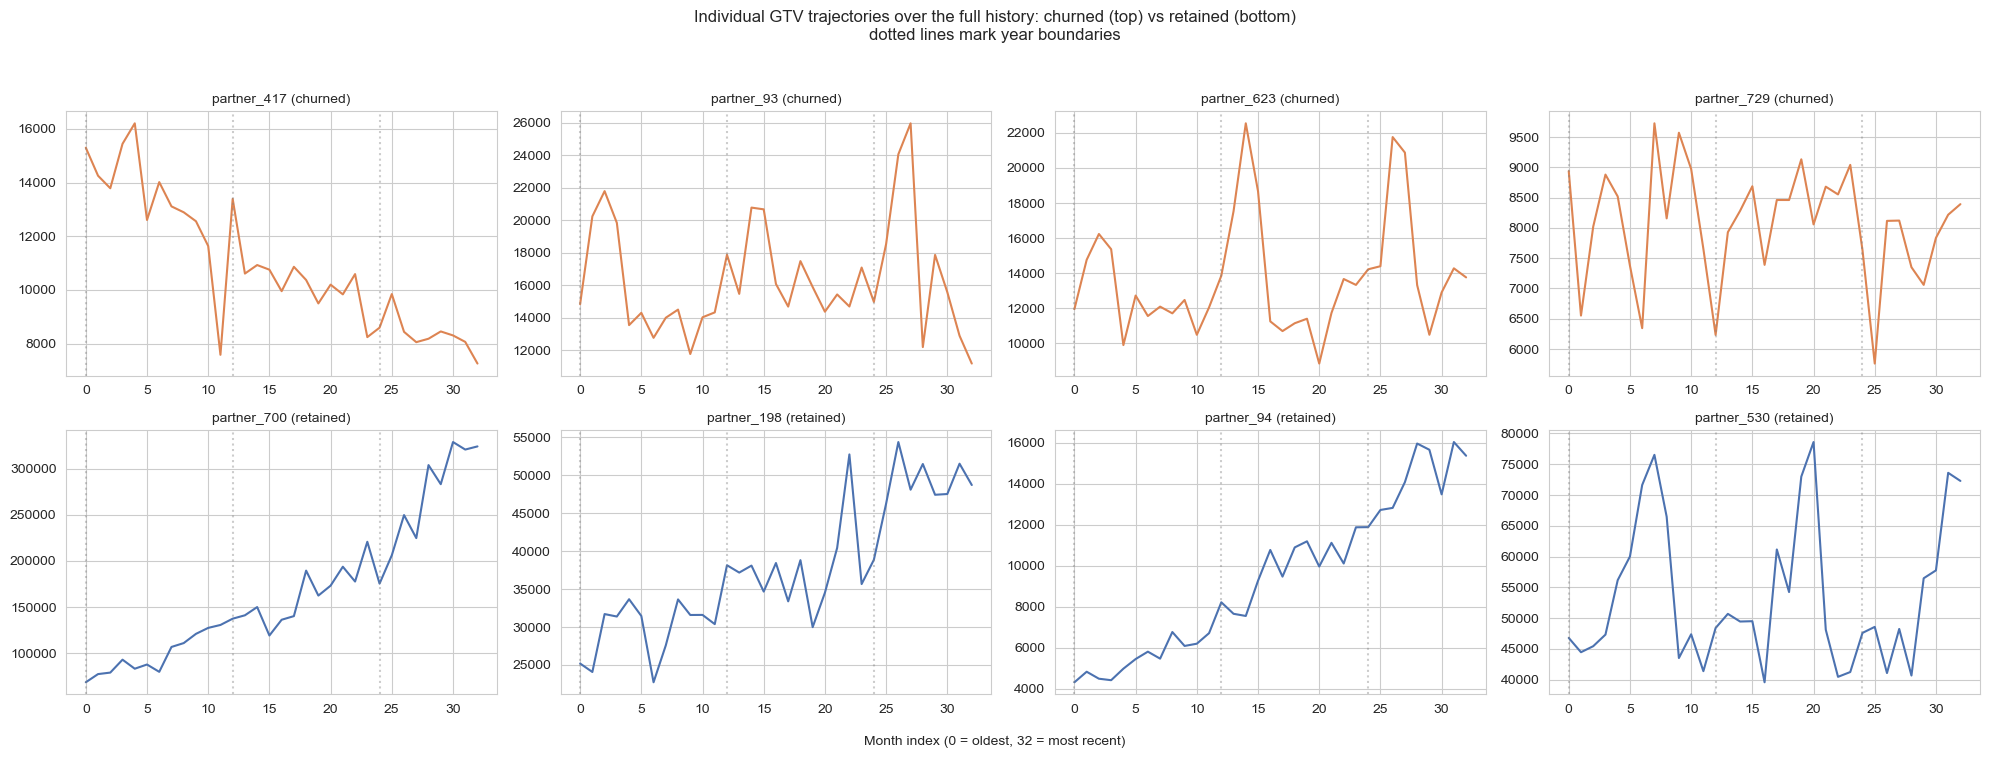

In [10]:
hist = gtv_history.merge(
    train_df[["partner_id", "churned_next_quarter", "vertical", "has_seasonality"]],
    on="partner_id", how="inner"
)

rng = np.random.default_rng(RANDOM_STATE)
churned_sample = rng.choice(train_df.loc[train_df["churned_next_quarter"] == 1, "partner_id"], size=4, replace=False)
retained_sample = rng.choice(train_df.loc[train_df["churned_next_quarter"] == 0, "partner_id"], size=4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 7), sharey=False)

for ax, pid in zip(axes[0], churned_sample):
    series = hist[hist["partner_id"] == pid].sort_values("month_index")
    ax.plot(series["month_index"], series["gtv"], color="#DD8452")
    for yr in [0, 12, 24]:
        ax.axvline(yr, color="gray", linestyle=":", alpha=0.4)
    ax.set_title(f"{pid} (churned)", fontsize=10)

for ax, pid in zip(axes[1], retained_sample):
    series = hist[hist["partner_id"] == pid].sort_values("month_index")
    ax.plot(series["month_index"], series["gtv"], color="#4C72B0")
    for yr in [0, 12, 24]:
        ax.axvline(yr, color="gray", linestyle=":", alpha=0.4)
    ax.set_title(f"{pid} (retained)", fontsize=10)

fig.suptitle("Individual GTV trajectories over the full history: churned (top) vs retained (bottom)\ndotted lines mark year boundaries", y=1.03)
fig.text(0.5, -0.02, "Month index (0 = oldest, 32 = most recent)", ha="center")
plt.tight_layout()
plt.show()

### 2.5b The seasonality fix, before vs. after

This is the direct demonstration of item 1's fix. I'll find mature, seasonal partners whose *old* `gtv_trend_3m` reads as a sharp decline (below -20%) — the kind of reading that would have gotten them wrongly flagged as at-risk under the original feature — and compare that against their new `gtv_trend_yoy_3m` and `gtv_seasonal_deviation_pct`.

Mature seasonal partners in the train snapshot: 169
...of which the OLD gtv_trend_3m reads as a >20% decline: 23

Average reading for that group, three ways:
gtv_trend_3m                 -29.76
gtv_trend_yoy_3m              -1.10
gtv_seasonal_deviation_pct    -1.96
dtype: float64


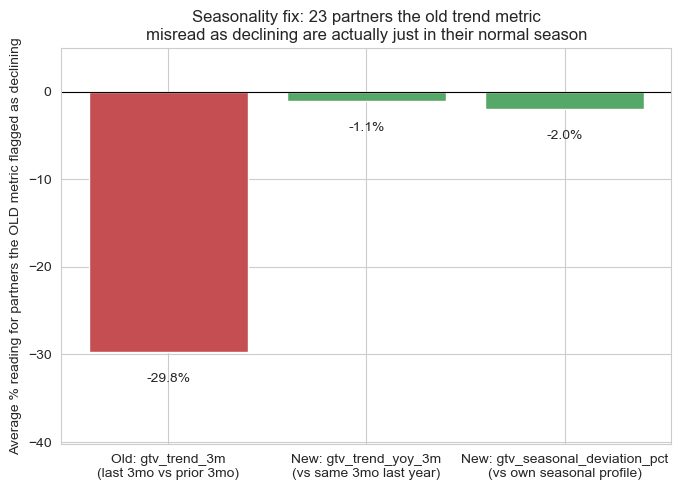

In [11]:
mature_seasonal = train_df[(train_df["scoring_path"] == "mature") & (train_df["has_seasonality"] == 1)]
false_alarms = mature_seasonal[mature_seasonal["gtv_trend_3m"] < -20]

print(f"Mature seasonal partners in the train snapshot: {len(mature_seasonal)}")
print(f"...of which the OLD gtv_trend_3m reads as a >20% decline: {len(false_alarms)}")
print()
print("Average reading for that group, three ways:")
avg_readings = false_alarms[["gtv_trend_3m", "gtv_trend_yoy_3m", "gtv_seasonal_deviation_pct"]].mean()
print(avg_readings.round(2))

plt.figure(figsize=(7, 5))
colors = ["#C44E52", "#55A868", "#55A868"]
bars = plt.bar(
    ["Old: gtv_trend_3m\n(last 3mo vs prior 3mo)", "New: gtv_trend_yoy_3m\n(vs same 3mo last year)",
     "New: gtv_seasonal_deviation_pct\n(vs own seasonal profile)"],
    avg_readings.values, color=colors
)
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Average % reading for partners the OLD metric flagged as declining")
plt.title(f"Seasonality fix: {len(false_alarms)} partners the old trend metric\nmisread as declining are actually just in their normal season")
ymin = min(avg_readings.values.min() * 1.35, -8)
plt.ylim(ymin, 5)
for bar, val in zip(bars, avg_readings.values):
    offset = 1.5 if val >= 0 else -0.06 * abs(ymin)
    va = "bottom" if val >= 0 else "top"
    plt.text(bar.get_x() + bar.get_width() / 2, val + offset, f"{val:.1f}%", ha="center", va=va)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "seasonal_trend_fix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

The old `gtv_trend_3m` averages a scary ~-28% for this group — exactly the kind of reading that would put a partner on a retention-outreach list. But their year-over-year trend and seasonal deviation both average close to 0%: these partners are right on their own normal seasonal pattern, not actually declining. This is the seasonality bug in action, and the fix: a seasonal partner's low season should read as *neutral*, not *at risk* — and now it does. The risk signal that should actually matter for a seasonal partner is `gtv_seasonal_deviation_pct` moving meaningfully negative — that's them falling behind their *own* history, which no normal seasonal trough would produce.

### 2.6 Cold-start segment: the cohort-ramp benchmark for new partners

Partners under 9 months tenure (`scoring_path == "new_partner"`) don't get the mature trend/seasonality block — those features are masked to a neutral value for them (see `src/data_pipeline.py`'s `mask_cold_start_features`). Instead they get `gtv_ramp_vs_cohort`: how their own early-tenure GTV ramp compares to peers at the same relative tenure stage.

New partners (train): 241 (24.1% of the book)
count    241.00
mean      19.80
std      101.58
min      -90.58
25%      -54.27
50%      -15.69
75%       52.54
max      300.00
Name: gtv_ramp_vs_cohort, dtype: float64


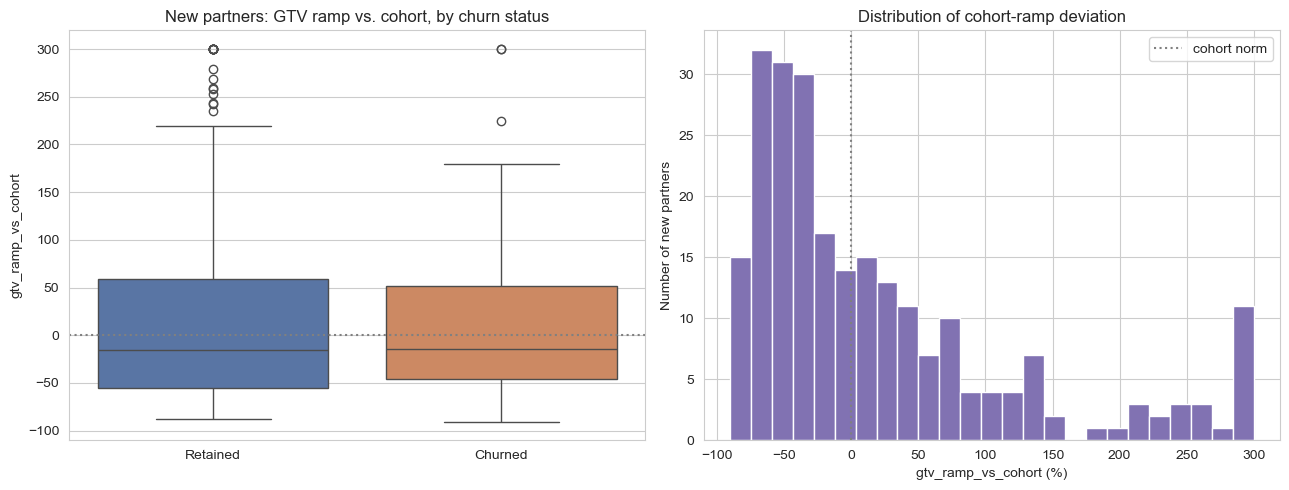

In [12]:
new_partners = train_df[train_df["scoring_path"] == "new_partner"]
mature_partners = train_df[train_df["scoring_path"] == "mature"]

print(f"New partners (train): {len(new_partners)} ({len(new_partners) / len(train_df):.1%} of the book)")
print(new_partners["gtv_ramp_vs_cohort"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=new_partners, x="churned_next_quarter", y="gtv_ramp_vs_cohort", ax=axes[0],
    hue="churned_next_quarter", palette=["#4C72B0", "#DD8452"], legend=False
)
axes[0].set_xticklabels(["Retained", "Churned"])
axes[0].set_xlabel("")
axes[0].set_title("New partners: GTV ramp vs. cohort, by churn status")
axes[0].axhline(0, color="gray", linestyle=":")

axes[1].hist(new_partners["gtv_ramp_vs_cohort"], bins=25, color="#8172B2")
axes[1].axvline(0, color="gray", linestyle=":", label="cohort norm")
axes[1].set_xlabel("gtv_ramp_vs_cohort (%)")
axes[1].set_ylabel("Number of new partners")
axes[1].set_title("Distribution of cohort-ramp deviation")
axes[1].legend()

plt.tight_layout()
plt.savefig(IMAGES_DIR / "cold_start_ramp_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

New partners ramping meaningfully behind their cohort (negative `gtv_ramp_vs_cohort`) don't show a strong split by churn status here — the correlation is close to zero. Worth being honest about why: the synthetic label-generating process in `generate_dataset.py` drives churn risk from the *raw* GTV trend (which is real and computable even for new partners, just unreliable to expose to the model this early), not from `gtv_ramp_vs_cohort` itself. So this feature isn't wired into the *ground truth* here — a limitation of how the synthetic data was constructed, not evidence that a cohort-ramp benchmark is a weak signal in a real partner program. The value of masking the mature block for new partners still stands on its own logic (their trend/seasonality features genuinely aren't reliable on a few months of history); confirming the masking itself worked as intended:

In [13]:
mature_block = ["gtv_trend_3m", "gtv_trend_yoy_3m", "gtv_seasonal_deviation_pct", "gtv_vs_peers"]
print("Unique values among new_partner rows (should be exactly 1 per column — the fixed neutral value):")
for col in mature_block:
    print(f"  {col}: {new_partners[col].nunique()} unique value(s) -> {new_partners[col].iloc[0]}")

print("\ngtv_ramp_vs_cohort among mature rows (should be exactly 0.0):")
print(mature_partners["gtv_ramp_vs_cohort"].unique())

Unique values among new_partner rows (should be exactly 1 per column — the fixed neutral value):
  gtv_trend_3m: 1 unique value(s) -> 1.28
  gtv_trend_yoy_3m: 1 unique value(s) -> 1.75
  gtv_seasonal_deviation_pct: 1 unique value(s) -> 0.0
  gtv_vs_peers: 1 unique value(s) -> 0.52

gtv_ramp_vs_cohort among mature rows (should be exactly 0.0):
[0.]


### 2.7 Outlier check

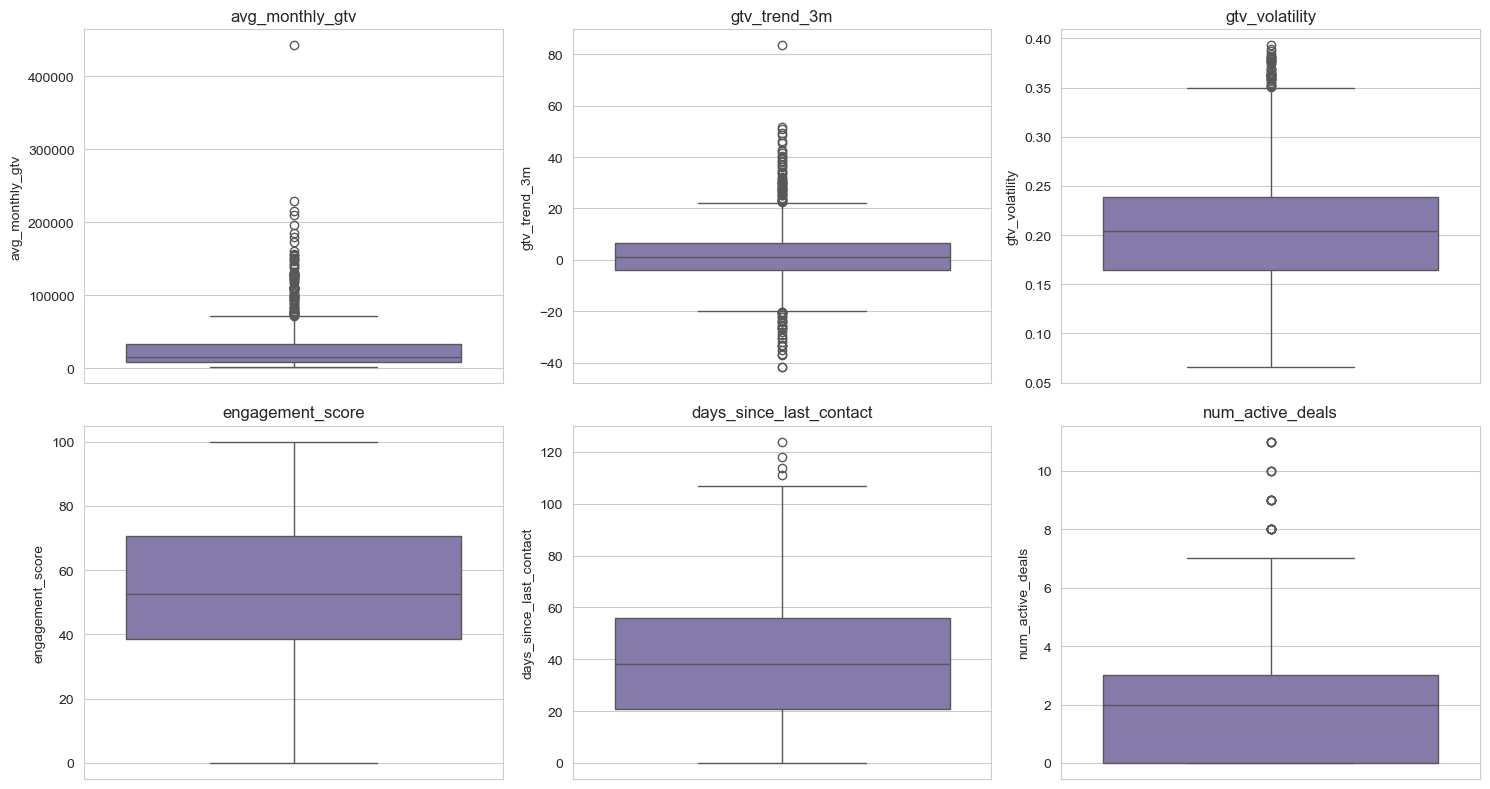

IQR-based outlier counts (values beyond 1.5x IQR from Q1/Q3):

avg_monthly_gtv              outliers:   83  (bounds: -29676.22 to 71818.03)
gtv_trend_3m                 outliers:   83  (bounds: -19.98 to 22.55)
gtv_volatility               outliers:   41  (bounds: 0.05 to 0.35)
engagement_score             outliers:    0  (bounds: -9.16 to 118.34)
days_since_last_contact      outliers:    4  (bounds: -31.50 to 108.50)
num_active_deals             outliers:   21  (bounds: -4.50 to 7.50)

Partners at the tenure floor (months_as_partner == 1): 109 of 1000
(These are partners who were very new as of the 'test' snapshot, whose earlier-snapshot
tenure was floored at 1 rather than allowed to go to 0 or negative — a documented
simplification in generate_dataset.py's compute_role_tenure, not a data error.)


In [14]:
outlier_check_cols = ["avg_monthly_gtv", "gtv_trend_3m", "gtv_volatility", "engagement_score", "days_since_last_contact", "num_active_deals"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), outlier_check_cols):
    sns.boxplot(data=train_df, y=col, ax=ax, color="#8172B2")
    ax.set_title(col)

plt.tight_layout()
plt.show()

print("IQR-based outlier counts (values beyond 1.5x IQR from Q1/Q3):\n")
for col in outlier_check_cols:
    q1, q3 = train_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    print(f"{col:28s} outliers: {n_outliers:4d}  (bounds: {lower:.2f} to {upper:.2f})")

n_tenure_floor = (train_df["months_as_partner"] == 1).sum()
print(f"\nPartners at the tenure floor (months_as_partner == 1): {n_tenure_floor} of {len(train_df)}")
print("(These are partners who were very new as of the 'test' snapshot, whose earlier-snapshot")
print("tenure was floored at 1 rather than allowed to go to 0 or negative — a documented")
print("simplification in generate_dataset.py's compute_role_tenure, not a data error.)")

`avg_monthly_gtv` still has a visible right tail (Strategic-tier partners transact at a materially larger scale), which is expected business structure, not a data error. The tenure-floor count is a small, expected cluster given how the `train` snapshot's tenure is derived — not large enough to distort the distribution, and explicitly documented rather than silently smoothed over.

### 2.8 EDA summary: my hypothesis before modeling

Based on everything above, here's what I'd bet on *before* looking at any model output:

1. **`gtv_trend_3m`** should still be a strong predictor overall (most partners aren't seasonal), but I'd expect **`gtv_seasonal_deviation_pct`** to matter more than `gtv_trend_3m` specifically *within* the seasonal-partner subgroup, now that it isn't confounded with normal seasonal troughs.
2. **`nps_score`** / **`nps_trend`** should rank highly — satisfaction remains a classic leading indicator, and the box plots back that up.
3. **`engagement_score`** should be a top driver — disengaged partners look meaningfully different in the box plots.
4. **`days_since_last_contact`** should matter — consistent with the correlation heatmap.
5. **`has_competitor_relationship`** should show a strong effect.
6. **`gtv_ramp_vs_cohort`** — section 2.6 already showed close to zero correlation with churn (a quirk of how the synthetic label was generated, not a real-world claim about ramp benchmarks — see that section's discussion). I'd expect it to rank low in feature importance despite being purpose-built for the new-partner segment; that's a fair, evidence-based expectation given what the EDA actually showed, not what I'd have hoped for going in.
7. **`has_seasonality`, `region`, `partner_tier`** should matter comparatively little on their own — none show a strong visual separation by churn status.

I'll compare this against what the models actually find important once we get past the temporal-split checkpoint below.

## 3. Preprocessing

I'll drop identifier/leakage-prone columns (`churn_probability` is the synthetic generator's internal probability; `seasonal_autocorr_lag12` is an intermediate statistic only used to derive `has_seasonality`), one-hot encode the categorical attributes (now including `scoring_path`), scale the numeric features, and split by `snapshot_role` — **not** a random `train_test_split`.

**Why a temporal split, not a random one:** once this model is deployed, it will only ever be asked to do one thing — score a partner's *current* state using a model trained on *past* data. It will never be asked to score a partner from the same point in time it was trained on, which is exactly what a random split silently evaluates. A random split can look great while hiding a model that's actually leaning on patterns specific to one moment (whatever happened to be true across the whole random 80/20 mix), not patterns that generalize forward. Splitting `train` (earliest snapshot) / `validation` (next) / `test` (latest, "the current book") measures the thing the model will actually be asked to do: given what's true as of an earlier point, how well do those learned patterns hold up on a later one.

In [15]:
model_df = snapshots_df.drop(columns=["churn_probability", "seasonal_autocorr_lag12"])

categorical_cols = ["region", "vertical", "partner_tier", "nps_trend", "scoring_path"]
id_cols = ["partner_id", "snapshot_role", "snapshot_cutoff_month"]
numeric_cols_model = [
    c for c in model_df.columns if c not in categorical_cols + id_cols + ["churned_next_quarter"]
]


def split_role(role):
    role_df = model_df[model_df["snapshot_role"] == role]
    X = role_df.drop(columns=id_cols + ["churned_next_quarter"])
    y = role_df["churned_next_quarter"]
    return X, y


X_train, y_train = split_role("train")
X_validation, y_validation = split_role("validation")
X_test, y_test = split_role("test")

print(f"Train:      {X_train.shape},      churn rate {y_train.mean():.1%}  (cutoff month 26, 27 months trailing history)")
print(f"Validation: {X_validation.shape}, churn rate {y_validation.mean():.1%}  (cutoff month 29, 30 months trailing history)")
print(f"Test:       {X_test.shape},       churn rate {y_test.mean():.1%}  (cutoff month 32, 33 months trailing history — \"now\")")

Train:      (1000, 22),      churn rate 20.0%  (cutoff month 26, 27 months trailing history)
Validation: (1000, 22), churn rate 18.9%  (cutoff month 29, 30 months trailing history)
Test:       (1000, 22),       churn rate 19.2%  (cutoff month 32, 33 months trailing history — "now")


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols_model),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    ]
)

**One more note on this split, worth stating precisely rather than glossing over:** the same `partner_id` appears in `train`, `validation`, and `test` (each partner has one row per snapshot). This is *not* temporal leakage — every snapshot's features are computed strictly from history truncated at that snapshot's own cutoff, so no future information reaches backward into an earlier snapshot. It's also the correct mirror of how the model will really be used: retrain periodically on the full historical partner-quarter table (which necessarily contains every partner's past snapshots), then score the current book going forward. What this split does **not** validate is a different generalization question — how well the model performs on a `partner_id` it has never seen in any snapshot. Item 2's cold-start segment partially addresses new partners specifically, but genuinely unseen-partner generalization isn't directly tested here.

## 4. Modeling

Four models, trained on `train`, model **selection** done on `validation` (never `test`), final metrics reported on `test` only. Same four algorithms as before: Logistic Regression, SVM, Random Forest, Gradient Boosting — with recall as the priority metric.

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

fitted_pipelines = {}
validation_results = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_validation)
    y_proba = pipe.predict_proba(X_validation)[:, 1]

    validation_results[name] = {
        "precision": precision_score(y_validation, y_pred),
        "recall": recall_score(y_validation, y_pred),
        "f1": f1_score(y_validation, y_pred),
        "roc_auc": roc_auc_score(y_validation, y_proba),
    }

validation_results_df = pd.DataFrame(validation_results).T.round(3)
print("Model selection metrics (on VALIDATION, never test):")
validation_results_df.sort_values("recall", ascending=False)

Model selection metrics (on VALIDATION, never test):


,precision,recall,f1,roc_auc
Logistic Regression,0.632,0.571,0.600,0.892
SVM,0.687,0.534,0.601,0.863
Random Forest,0.709,0.529,0.606,0.888
Gradient Boosting,0.616,0.519,0.563,0.881


In [18]:
best_model_name = validation_results_df["recall"].idxmax()
print(f"Best model by recall on validation: {best_model_name}")

test_results = {}
for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    test_results[name] = {
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

test_results_df = pd.DataFrame(test_results).T.round(3)
print("\nFinal reported metrics (on TEST — the honest, forward-looking read):")
test_results_df.sort_values("recall", ascending=False)

Best model by recall on validation: Logistic Regression

Final reported metrics (on TEST — the honest, forward-looking read):


,precision,recall,f1,roc_auc
Logistic Regression,0.597,0.562,0.579,0.878
Gradient Boosting,0.575,0.521,0.546,0.871
SVM,0.601,0.510,0.552,0.844
Random Forest,0.629,0.495,0.554,0.874


### 4.1 Confusion matrices (test)

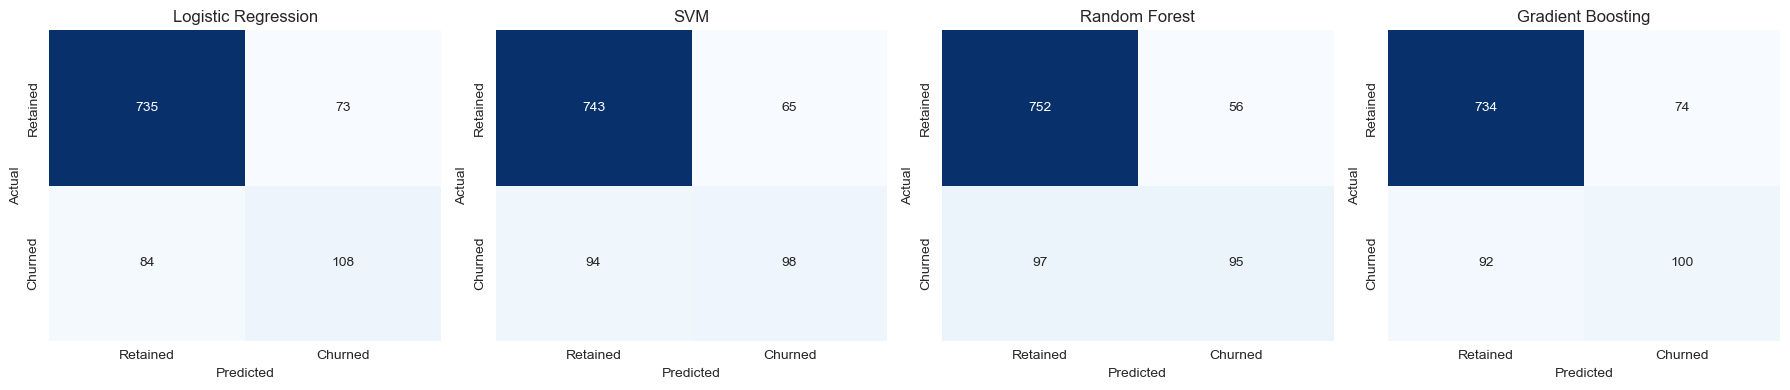

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### 4.2 ROC curves (test)

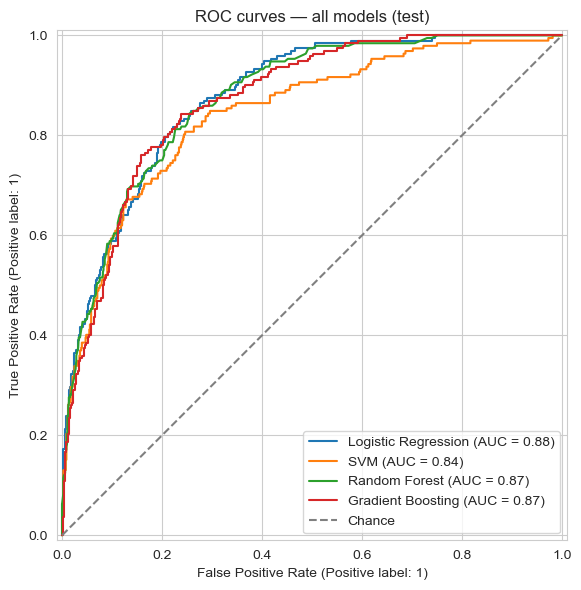

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC curves — all models (test)")
ax.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "roc_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.3 Precision-recall tradeoff for the best model (test)

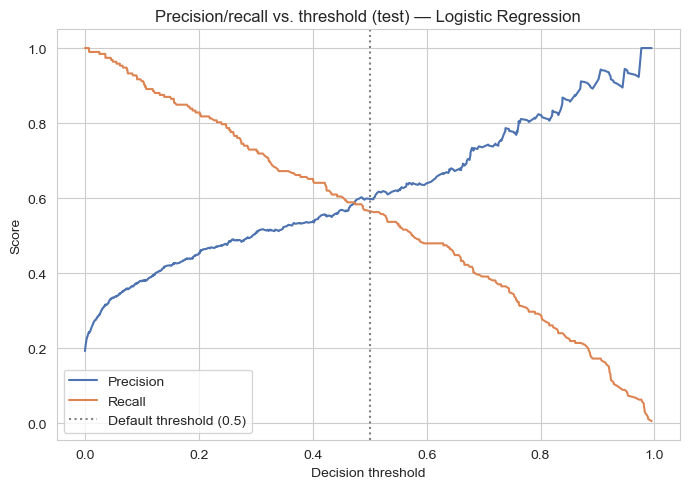

In [21]:
best_pipe = fitted_pipelines[best_model_name]
y_proba_pr = best_pipe.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_pr)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label="Precision", color="#4C72B0")
plt.plot(thresholds, recalls[:-1], label="Recall", color="#DD8452")
plt.axvline(0.5, color="gray", linestyle=":", label="Default threshold (0.5)")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title(f"Precision/recall vs. threshold (test) — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

This default-0.5 view is a placeholder — the cost-based threshold section later in this notebook replaces it with a threshold actually derived from the asymmetry between a missed churn and an unnecessary call, tuned on `validation` and only then confirmed on `test`.

### 4.4 Classification reports (test)

In [22]:
for name, pipe in fitted_pipelines.items():
    print(f"--- {name} ---")
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

--- Logistic Regression ---
              precision    recall  f1-score   support

    Retained       0.90      0.91      0.90       808
     Churned       0.60      0.56      0.58       192

    accuracy                           0.84      1000
   macro avg       0.75      0.74      0.74      1000
weighted avg       0.84      0.84      0.84      1000

--- SVM ---
              precision    recall  f1-score   support

    Retained       0.89      0.92      0.90       808
     Churned       0.60      0.51      0.55       192

    accuracy                           0.84      1000
   macro avg       0.74      0.71      0.73      1000
weighted avg       0.83      0.84      0.84      1000

--- Random Forest ---
              precision    recall  f1-score   support

    Retained       0.89      0.93      0.91       808
     Churned       0.63      0.49      0.55       192

    accuracy                           0.85      1000
   macro avg       0.76      0.71      0.73      1000
weighted avg

### 4.5 Old (random split) vs. new (temporal split): an honest comparison

The original version of this notebook evaluated on a random 80/20 split of a single point-in-time snapshot. Here's how those numbers compare to the new temporal `test`-set evaluation.

In [23]:
old_random_split_results = pd.DataFrame({
    "Logistic Regression": {"precision": 0.650, "recall": 0.650, "f1": 0.650, "roc_auc": 0.916},
    "Gradient Boosting":   {"precision": 0.677, "recall": 0.525, "f1": 0.592, "roc_auc": 0.912},
    "SVM":                 {"precision": 0.667, "recall": 0.500, "f1": 0.571, "roc_auc": 0.897},
    "Random Forest":       {"precision": 0.708, "recall": 0.425, "f1": 0.531, "roc_auc": 0.908},
}).T

comparison = old_random_split_results.join(
    test_results_df, lsuffix="_OLD_random_split", rsuffix="_NEW_temporal_split"
)
comparison = comparison[sorted(comparison.columns)]
comparison

,f1_NEW_temporal_split,f1_OLD_random_split,precision_NEW_temporal_split,precision_OLD_random_split,recall_NEW_temporal_split,recall_OLD_random_split,roc_auc_NEW_temporal_split,roc_auc_OLD_random_split
Logistic Regression,0.579,0.650,0.597,0.650,0.562,0.650,0.878,0.916
Gradient Boosting,0.546,0.592,0.575,0.677,0.521,0.525,0.871,0.912
SVM,0.552,0.571,0.601,0.667,0.510,0.500,0.844,0.897
Random Forest,0.554,0.531,0.629,0.708,0.495,0.425,0.874,0.908


**Reading this table honestly:** any drop from the old numbers to the new ones isn't a regression to fix — it's the old numbers having been *too optimistic*, because a random split let the model implicitly see patterns from the same time window it was tested on. The new temporal-split numbers are a more honest estimate of what this model will actually achieve once deployed, scoring a book of partners it's never seen a snapshot of before. If anything, a big gap between the two is useful information on its own: it tells us how much the original evaluation was overstating real-world performance, which is exactly the kind of thing you want to know *before* shipping a model, not after.

**★ Checkpoint: this is where I'm stopping to report before continuing to the cost-based threshold, SHAP, and survival-analysis sections.** The feature-set fixes (seasonality, cold-start) and the harder, more honest temporal evaluation are now in place — everything after this point in the plan builds on top of these results, so it's worth confirming they look right first.